# Weather SGH — Analiza historyczna & Trening modelu ML

**Projekt:** Monitoring pogody w czasie rzeczywistym (SGH, 52.25°N 21.0°E)  
**Dane:** tabela `weather_raw` w PostgreSQL — dane godzinowe z Open-Meteo archive + dane live co 15 min  

---
## 1. Importy i konfiguracja

In [152]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sqlalchemy import create_engine, text

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
sns.set_theme(style='whitegrid')

print('Biblioteki załadowane.')

Biblioteki załadowane.


## 2. Połączenie z bazą danych i wczytanie danych

In [153]:
DB_HOST = os.environ.get('POSTGRES_HOST', 'localhost')
DB_PORT = os.environ.get('POSTGRES_PORT', '5432')
DB_NAME = os.environ.get('POSTGRES_DB', 'weather')
DB_USER = os.environ.get('POSTGRES_USER', 'weather_user')
DB_PASS = os.environ.get('POSTGRES_PASSWORD', 'weather_pass')

engine = create_engine(
    f'postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
)

with engine.connect() as conn:
    result = conn.execute(text('SELECT COUNT(*) FROM weather_raw')).scalar()

print(f'Połączono z bazą. Liczba rekordów w weather_raw: {result:,}')

Połączono z bazą. Liczba rekordów w weather_raw: 56,455


In [154]:
QUERY = """
SELECT
    measured_at,
    temp_c,
    feels_like_c,
    pressure_hpa,
    humidity_pct,
    visibility_m,
    wind_speed_ms,
    wind_deg,
    wind_gust_ms,
    clouds_pct,
    rain_1h_mm,
    snow_1h_mm,
    weather_main
FROM weather_raw
ORDER BY measured_at ASC
"""

df = pd.read_sql(QUERY, engine, parse_dates=['measured_at'])
df = df.set_index('measured_at')
df.index = df.index.tz_convert('Europe/Warsaw')

print(f'Wczytano {len(df):,} rekordów')
print(f'Zakres dat: {df.index.min()} → {df.index.max()}')
print(f'Liczba dni: {(df.index.max() - df.index.min()).days}')

Wczytano 56,455 rekordów
Zakres dat: 2020-01-01 01:00:00+01:00 → 2026-06-10 01:00:00+02:00
Liczba dni: 2351


## 3. Przegląd danych

In [155]:
print('Wymiary DataFrame:', df.shape)
print()
print('Typy kolumn:')
print(df.dtypes)

Wymiary DataFrame: (56455, 12)

Typy kolumn:
temp_c           float64
feels_like_c     float64
pressure_hpa     float64
humidity_pct       int64
visibility_m     float64
wind_speed_ms    float64
wind_deg           int64
wind_gust_ms     float64
clouds_pct         int64
rain_1h_mm       float64
snow_1h_mm       float64
weather_main         str
dtype: object


In [156]:
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)
null_summary = pd.DataFrame({'braki': null_counts, 'procent': null_pct})
print('Braki danych:')
print(null_summary[null_summary['braki'] > 0].to_string())

Braki danych:
              braki  procent
visibility_m  56445   99.980
snow_1h_mm       10    0.020


In [157]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
temp_c,56455.000,9.900,8.768,-21.500,3.000,9.400,16.800,35.700
feels_like_c,56455.000,7.295,10.359,-26.500,-1.000,6.400,15.600,36.600
pressure_hpa,56455.000,1016.045,9.046,975.900,1010.500,1016.300,1021.700,1047.600
humidity_pct,56455.000,75.009,18.214,15.000,63.000,79.000,90.000,100.000
visibility_m,10.000,12148.000,2499.586,9280.000,9825.000,11950.000,13930.000,16360.000
wind_speed_ms,56455.000,3.426,1.646,0.000,2.220,3.200,4.350,13.890
wind_deg,56455.000,201.091,93.627,0.000,131.000,218.000,275.000,360.000
wind_gust_ms,56455.000,7.067,3.203,0.300,4.700,6.600,8.900,30.300
clouds_pct,56455.000,66.401,39.820,0.000,25.000,93.000,100.000,100.000
rain_1h_mm,56455.000,0.077,0.345,0.000,0.000,0.000,0.000,18.700


In [158]:
df['rain_1h_mm'] = df['rain_1h_mm'].fillna(0.0)
df['snow_1h_mm'] = df['snow_1h_mm'].fillna(0.0)
df['wind_gust_ms'] = df['wind_gust_ms'].fillna(df['wind_speed_ms'])

numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols] = df[numeric_cols].interpolate(method='time')

print('Po uzupełnieniu — pozostałe braki:')
remaining = df.isnull().sum()
print(remaining[remaining > 0].to_string() if remaining.sum() > 0 else 'Brak.')

Po uzupełnieniu — pozostałe braki:
visibility_m    56443


In [159]:
print('=== Pierwsze rekordy ===')
display(df.head(3))
print('=== Ostatnie rekordy ===')
display(df.tail(3))

=== Pierwsze rekordy ===


,temp_c,feels_like_c,pressure_hpa,humidity_pct,visibility_m,wind_speed_ms,wind_deg,wind_gust_ms,clouds_pct,rain_1h_mm,snow_1h_mm,weather_main
measured_at,,,,,,,,,,,,
2020-01-01 01:00:00+01:00,3.000,-2.400,1025.300,76,NaN,5.960,305,11.700,54,0.000,0.000,Clouds
2020-01-01 02:00:00+01:00,2.800,-2.400,1026.200,76,NaN,5.520,302,11.000,75,0.000,0.000,Clouds
2020-01-01 03:00:00+01:00,2.800,-2.200,1026.700,77,NaN,5.160,302,10.300,51,0.000,0.000,Clouds


=== Ostatnie rekordy ===


,temp_c,feels_like_c,pressure_hpa,humidity_pct,visibility_m,wind_speed_ms,wind_deg,wind_gust_ms,clouds_pct,rain_1h_mm,snow_1h_mm,weather_main
measured_at,,,,,,,,,,,,
2026-06-09 23:15:00+02:00,19.100,19.300,1013.100,89,9280.000,4.600,292,9.500,100,0.100,0.000,Drizzle
2026-06-10 00:00:00+02:00,18.400,19.000,1014.300,89,9280.000,2.960,286,7.000,98,0.000,0.000,Clouds
2026-06-10 01:00:00+02:00,17.600,17.800,1014.700,91,9280.000,3.530,297,8.400,97,0.100,0.000,Drizzle


---
## 4. EDA — Eksploracyjna Analiza Danych

### 4.1 Rozkłady zmiennych

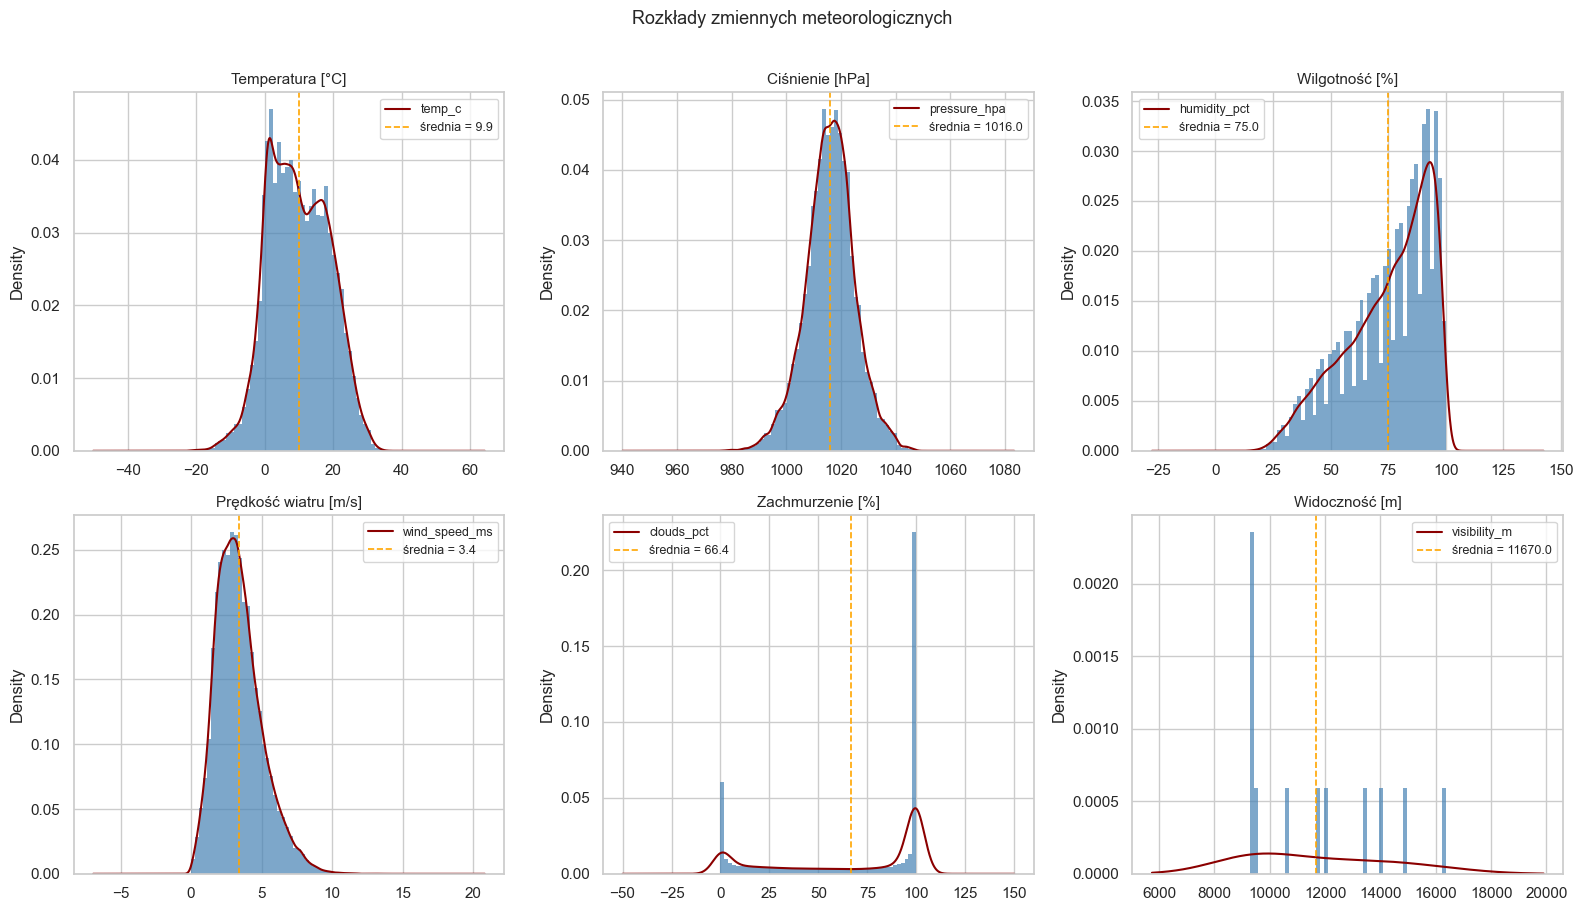

In [160]:
eda_cols = [
    ('temp_c',        'Temperatura [°C]'),
    ('pressure_hpa',  'Ciśnienie [hPa]'),
    ('humidity_pct',  'Wilgotność [%]'),
    ('wind_speed_ms', 'Prędkość wiatru [m/s]'),
    ('clouds_pct',    'Zachmurzenie [%]'),
    ('visibility_m',  'Widoczność [m]'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (col, label) in zip(axes, eda_cols):
    data = df[col].dropna()
    ax.hist(data, bins=50, color='steelblue', alpha=0.7, edgecolor='none', density=True)
    data.plot.kde(ax=ax, color='darkred', linewidth=1.5)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('')
    mean_val = data.mean()
    ax.axvline(mean_val, color='orange', linestyle='--', linewidth=1.2,
               label=f'średnia = {mean_val:.1f}')
    ax.legend(fontsize=9)

plt.suptitle('Rozkłady zmiennych meteorologicznych', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

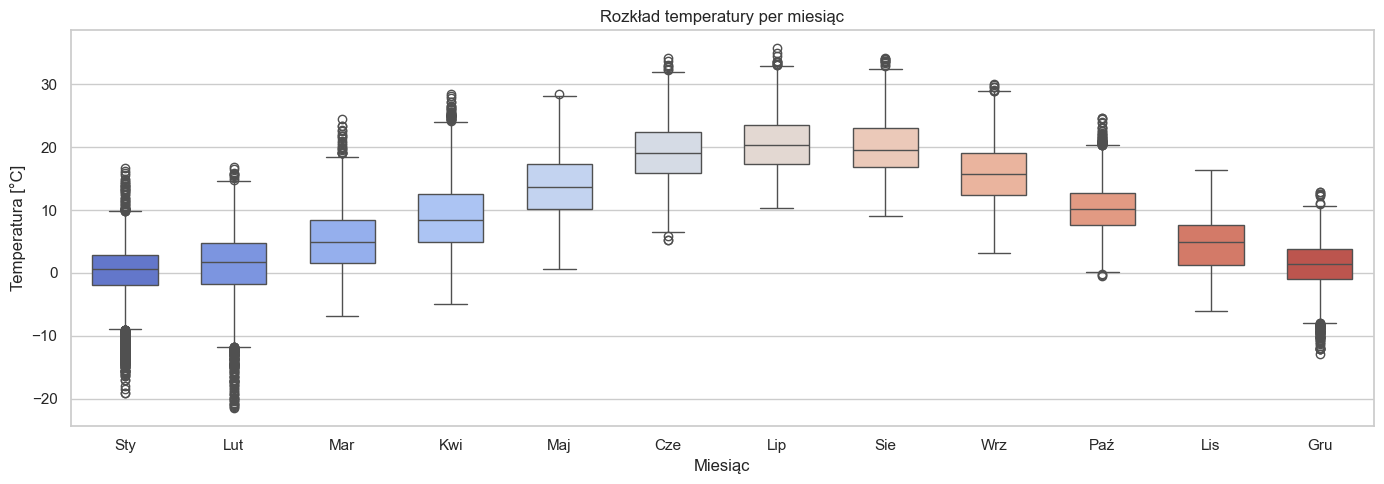

In [161]:
df_box = df.copy()
df_box['miesiac'] = df_box.index.month
MONTH_NAMES = {1:'Sty',2:'Lut',3:'Mar',4:'Kwi',5:'Maj',6:'Cze',
               7:'Lip',8:'Sie',9:'Wrz',10:'Paź',11:'Lis',12:'Gru'}
df_box['miesiac_str'] = df_box['miesiac'].map(MONTH_NAMES)
months_present = sorted(df_box['miesiac'].unique())
order = [MONTH_NAMES[m] for m in months_present]

fig, ax = plt.subplots(figsize=(14, 5))
sns.boxplot(data=df_box, x='miesiac_str', y='temp_c', order=order,
            palette='coolwarm', ax=ax, width=0.6)
ax.set_title('Rozkład temperatury per miesiąc', fontsize=12)
ax.set_xlabel('Miesiąc')
ax.set_ylabel('Temperatura [°C]')
plt.tight_layout()
plt.show()

### 4.2 Szeregi czasowe

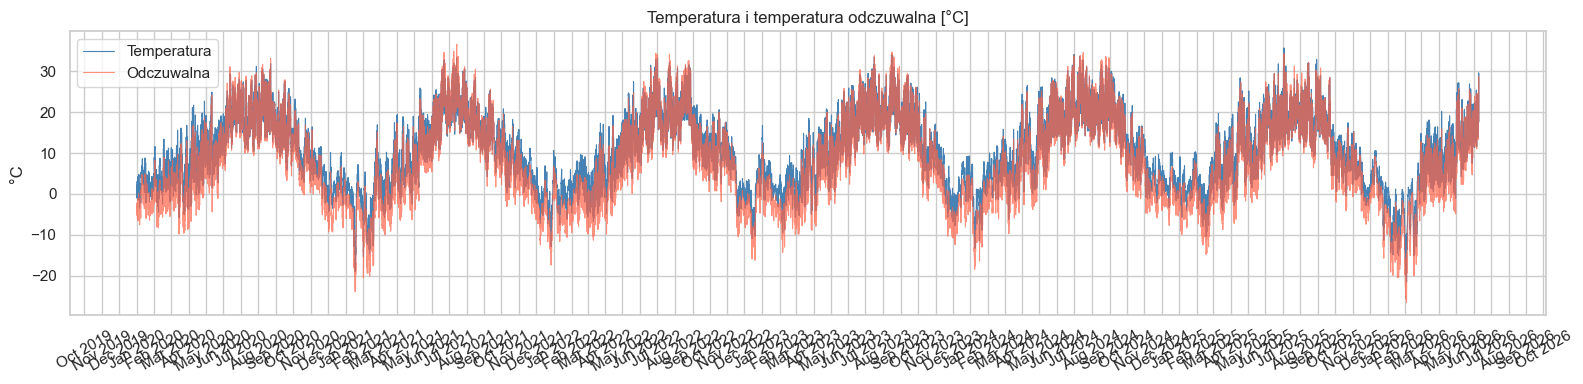

In [162]:
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df.index, df['temp_c'], color='steelblue', linewidth=0.8, label='Temperatura')
ax.plot(df.index, df['feels_like_c'], color='tomato', linewidth=0.8,
        alpha=0.7, label='Odczuwalna')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=30)
ax.set_title('Temperatura i temperatura odczuwalna [°C]')
ax.set_ylabel('°C')
ax.legend()
plt.tight_layout()
plt.show()

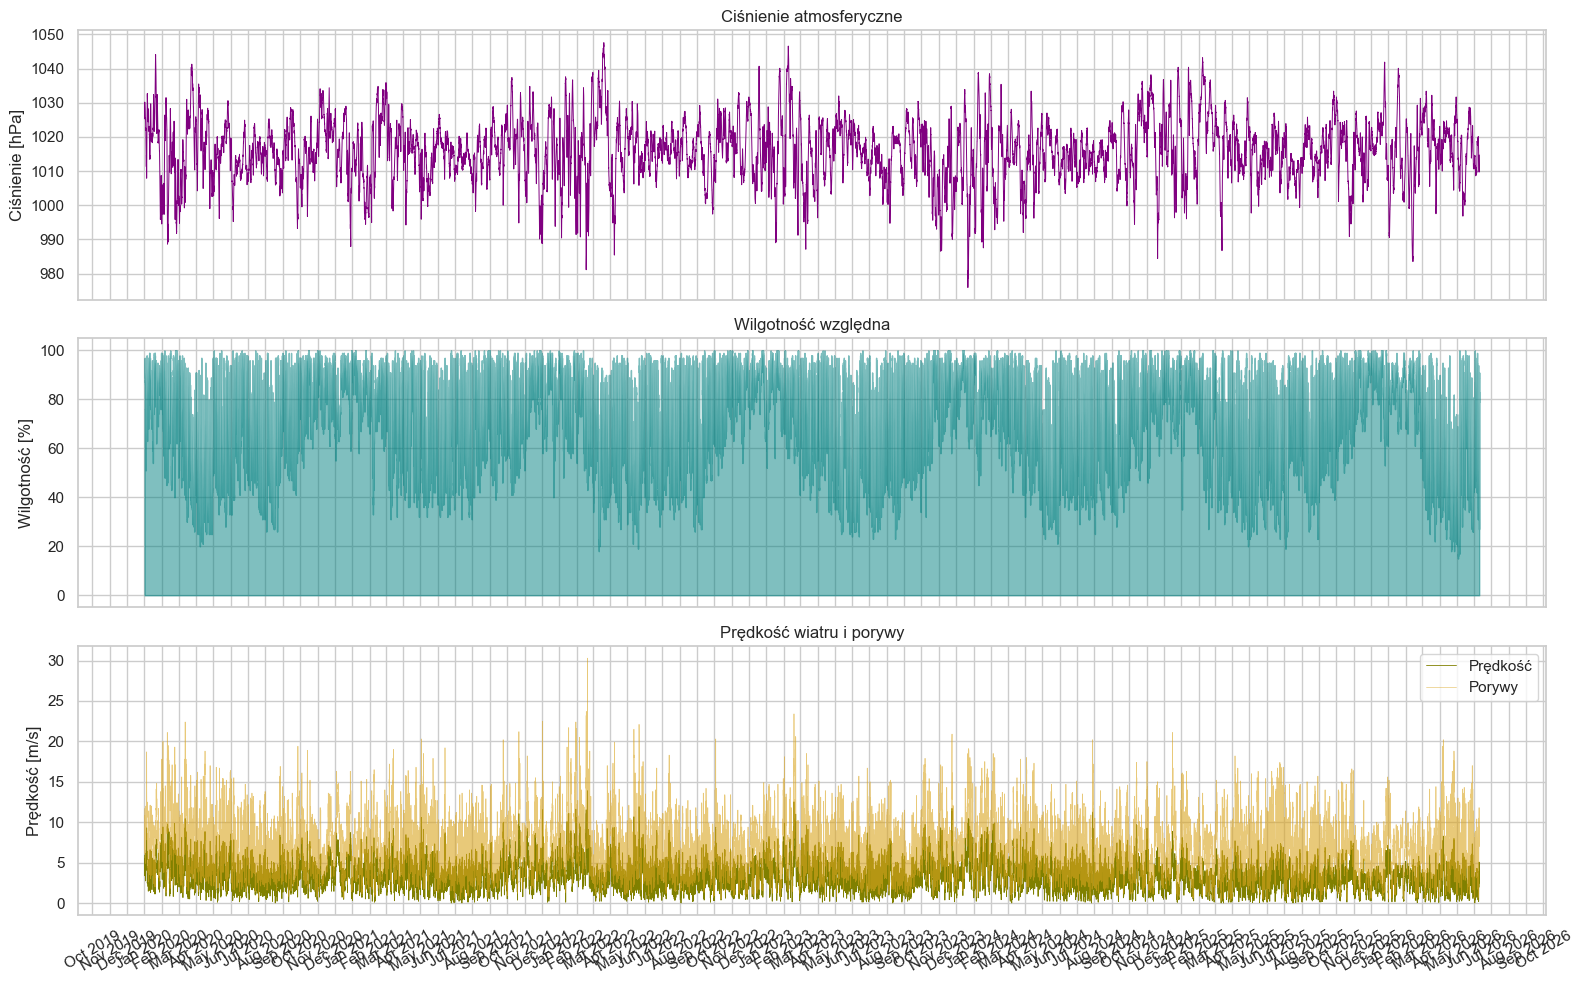

In [163]:
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

axes[0].plot(df.index, df['pressure_hpa'], color='purple', linewidth=0.7)
axes[0].set_ylabel('Ciśnienie [hPa]')
axes[0].set_title('Ciśnienie atmosferyczne')

axes[1].fill_between(df.index, df['humidity_pct'], alpha=0.5, color='teal')
axes[1].set_ylabel('Wilgotność [%]')
axes[1].set_title('Wilgotność względna')

axes[2].plot(df.index, df['wind_speed_ms'], color='olive', linewidth=0.6, label='Prędkość')
axes[2].plot(df.index, df['wind_gust_ms'], color='goldenrod', linewidth=0.5,
             alpha=0.6, label='Porywy')
axes[2].set_ylabel('Prędkość [m/s]')
axes[2].set_title('Prędkość wiatru i porywy')
axes[2].legend()

axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[2].xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Godziny z opadami deszczu: 9514 (16.9%)
Godziny z opadami śniegu:  1606 (2.8%)


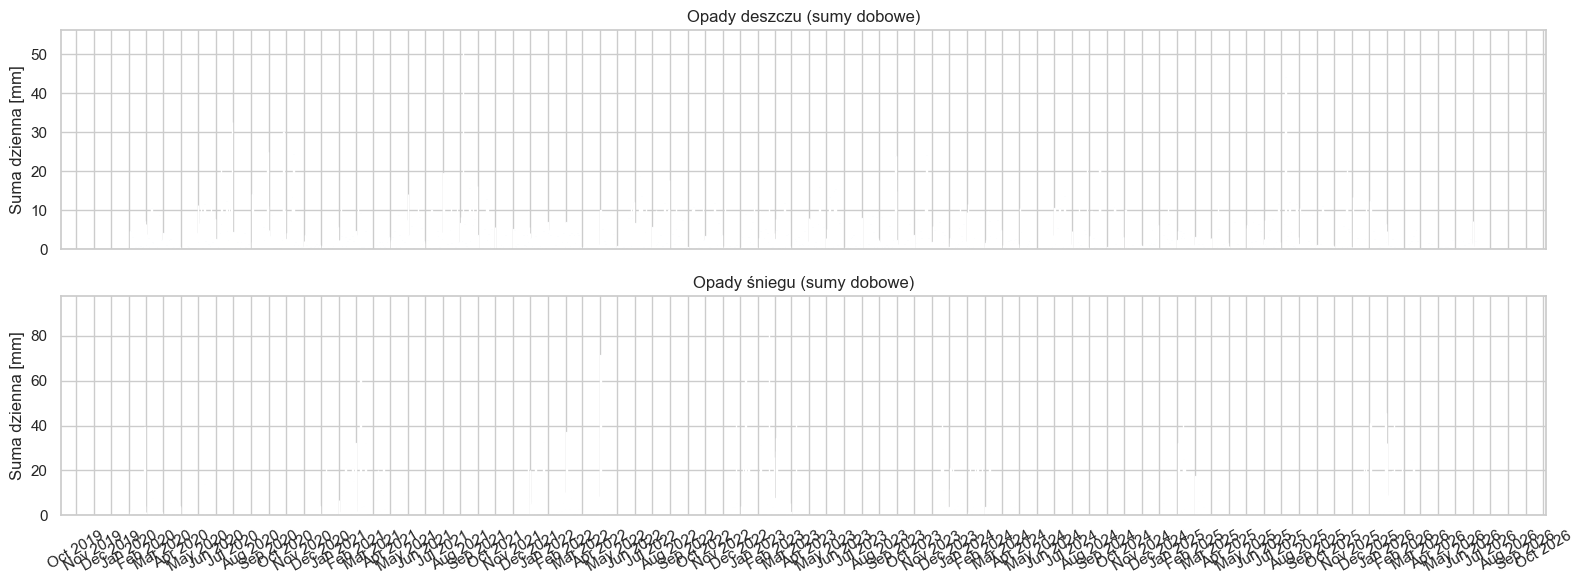

In [164]:
rain_hours = (df['rain_1h_mm'] > 0).sum()
snow_hours = (df['snow_1h_mm'] > 0).sum()
print(f'Godziny z opadami deszczu: {rain_hours} ({rain_hours/len(df)*100:.1f}%)')
print(f'Godziny z opadami śniegu:  {snow_hours} ({snow_hours/len(df)*100:.1f}%)')

# Resampling do sum dobowych — słupki godzinowe byłyby niewidoczne w 160-dniowej skali
rain_daily = df['rain_1h_mm'].resample('D').sum()
snow_daily = df['snow_1h_mm'].resample('D').sum()

fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=True)

axes[0].bar(rain_daily.index, rain_daily.values, color='royalblue', width=0.8)
axes[0].set_ylabel('Suma dzienna [mm]')
axes[0].set_title('Opady deszczu (sumy dobowe)')

axes[1].bar(snow_daily.index, snow_daily.values, color='lightblue', width=0.8)
axes[1].set_ylabel('Suma dzienna [mm]')
axes[1].set_title('Opady śniegu (sumy dobowe)')

axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### 4.3 Sezonowość dzienna i tygodniowa

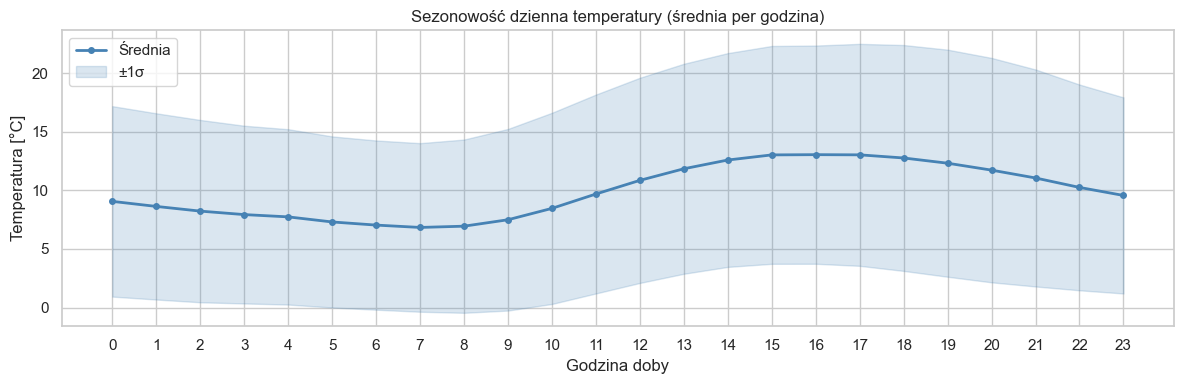

In [165]:
df_hourly = df.copy()
df_hourly['hour'] = df_hourly.index.hour
hourly_stats = df_hourly.groupby('hour')['temp_c'].agg(['mean', 'std'])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hourly_stats.index, hourly_stats['mean'], color='steelblue',
        linewidth=2, marker='o', markersize=4, label='Średnia')
ax.fill_between(
    hourly_stats.index,
    hourly_stats['mean'] - hourly_stats['std'],
    hourly_stats['mean'] + hourly_stats['std'],
    alpha=0.2, color='steelblue', label='±1σ'
)
ax.set_xticks(range(0, 24))
ax.set_xlabel('Godzina doby')
ax.set_ylabel('Temperatura [°C]')
ax.set_title('Sezonowość dzienna temperatury (średnia per godzina)')
ax.legend()
plt.tight_layout()
plt.show()

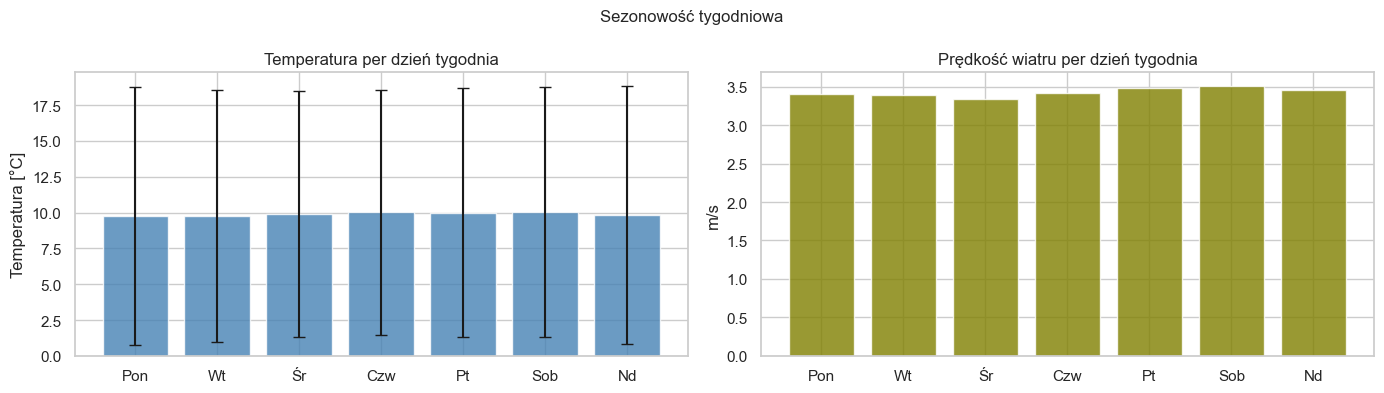

In [166]:
DAY_NAMES = ['Pon', 'Wt', 'Śr', 'Czw', 'Pt', 'Sob', 'Nd']
df_weekly = df.copy()
df_weekly['dayofweek'] = df_weekly.index.dayofweek
weekly_stats = df_weekly.groupby('dayofweek')['temp_c'].agg(['mean', 'std'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(DAY_NAMES, weekly_stats['mean'], color='steelblue',
            yerr=weekly_stats['std'], capsize=4, alpha=0.8)
axes[0].set_title('Temperatura per dzień tygodnia')
axes[0].set_ylabel('Temperatura [°C]')

wind_weekly = df_weekly.groupby('dayofweek')['wind_speed_ms'].mean()
axes[1].bar(DAY_NAMES, wind_weekly, color='olive', alpha=0.8)
axes[1].set_title('Prędkość wiatru per dzień tygodnia')
axes[1].set_ylabel('m/s')

plt.suptitle('Sezonowość tygodniowa', fontsize=12)
plt.tight_layout()
plt.show()

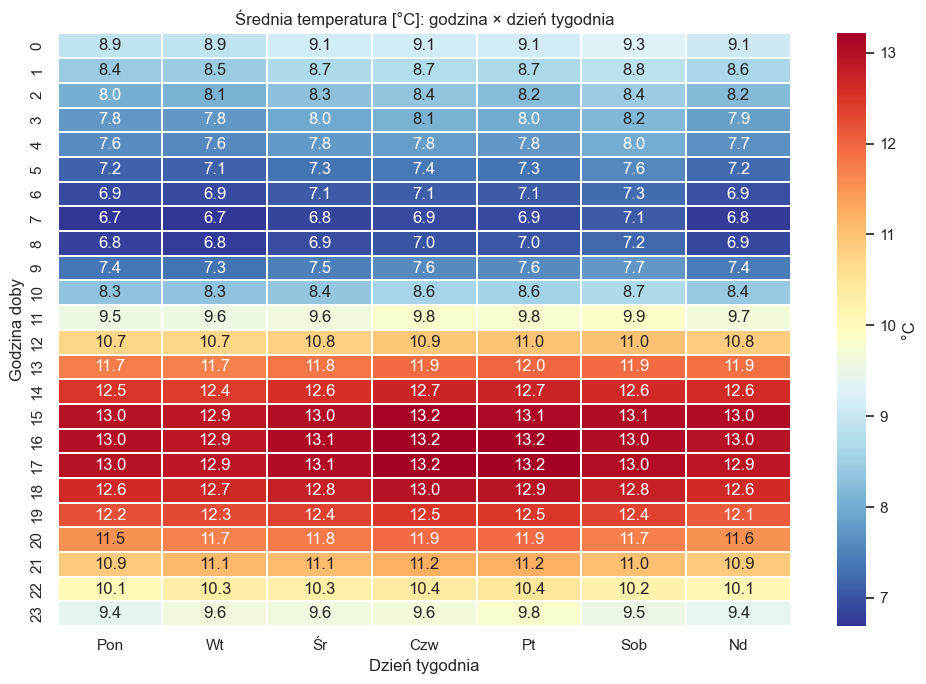

In [167]:
df_heat = df.copy()
df_heat['hour'] = df_heat.index.hour
df_heat['dayofweek'] = df_heat.index.dayofweek

pivot = df_heat.pivot_table(
    values='temp_c', index='hour', columns='dayofweek', aggfunc='mean'
)
pivot.columns = DAY_NAMES

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(pivot, cmap='RdYlBu_r', annot=True, fmt='.1f',
            linewidths=0.3, ax=ax, cbar_kws={'label': '°C'})
ax.set_title('Średnia temperatura [°C]: godzina × dzień tygodnia')
ax.set_xlabel('Dzień tygodnia')
ax.set_ylabel('Godzina doby')
plt.tight_layout()
plt.show()

### 4.4 Korelacje między zmiennymi

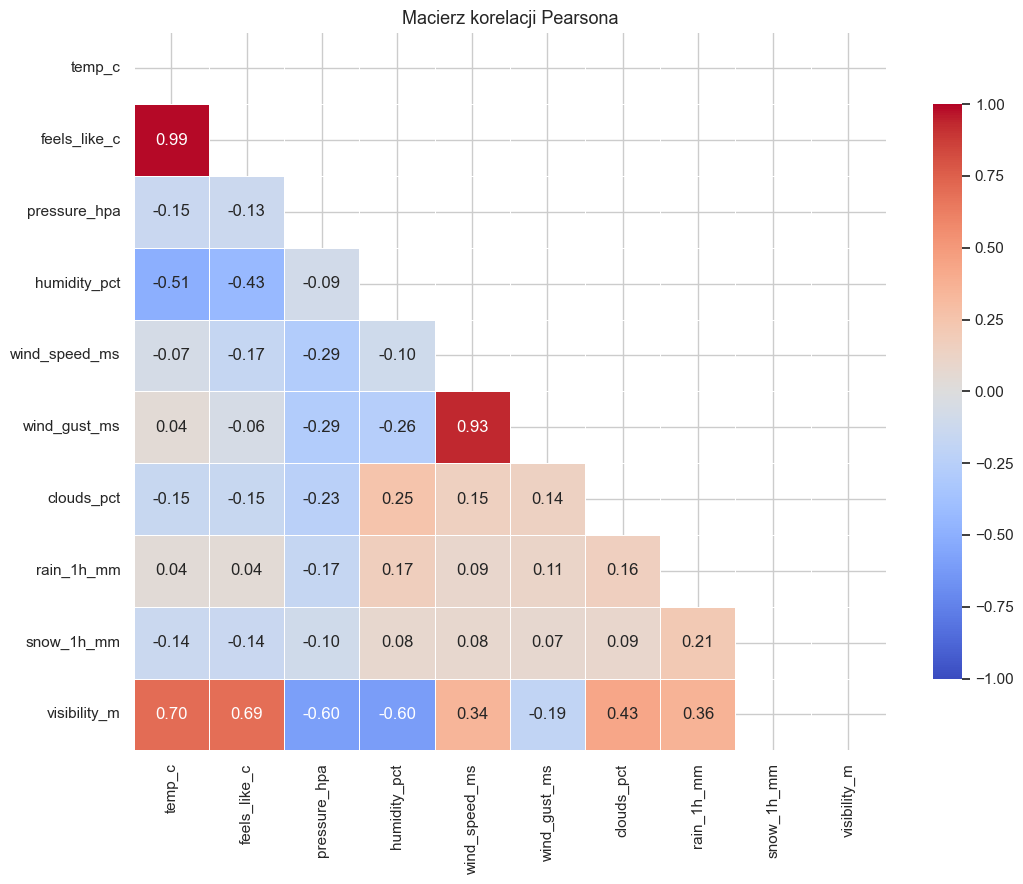

In [168]:
corr_cols = ['temp_c', 'feels_like_c', 'pressure_hpa', 'humidity_pct',
             'wind_speed_ms', 'wind_gust_ms', 'clouds_pct',
             'rain_1h_mm', 'snow_1h_mm', 'visibility_m']

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title('Macierz korelacji Pearsona', fontsize=13)
plt.tight_layout()
plt.show()

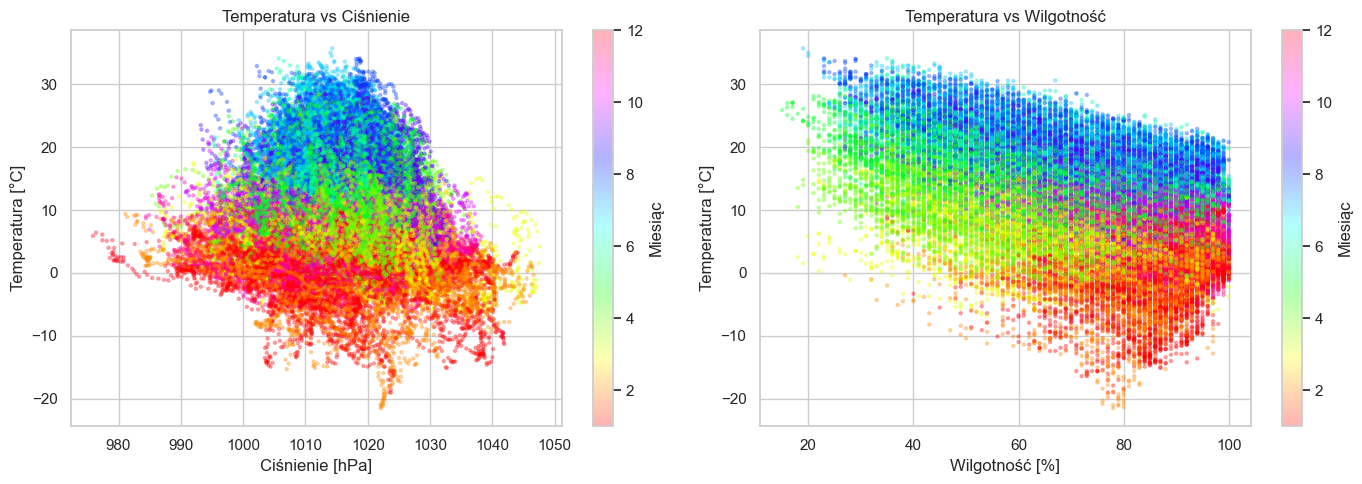

In [169]:
df_scatter = df.copy()
df_scatter['month'] = df_scatter.index.month

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc0 = axes[0].scatter(
    df_scatter['pressure_hpa'], df_scatter['temp_c'],
    c=df_scatter['month'], cmap='hsv', alpha=0.3, s=5
)
axes[0].set_xlabel('Ciśnienie [hPa]')
axes[0].set_ylabel('Temperatura [°C]')
axes[0].set_title('Temperatura vs Ciśnienie')
plt.colorbar(sc0, ax=axes[0], label='Miesiąc')

sc1 = axes[1].scatter(
    df_scatter['humidity_pct'], df_scatter['temp_c'],
    c=df_scatter['month'], cmap='hsv', alpha=0.3, s=5
)
axes[1].set_xlabel('Wilgotność [%]')
axes[1].set_ylabel('Temperatura [°C]')
axes[1].set_title('Temperatura vs Wilgotność')
plt.colorbar(sc1, ax=axes[1], label='Miesiąc')

plt.tight_layout()
plt.show()

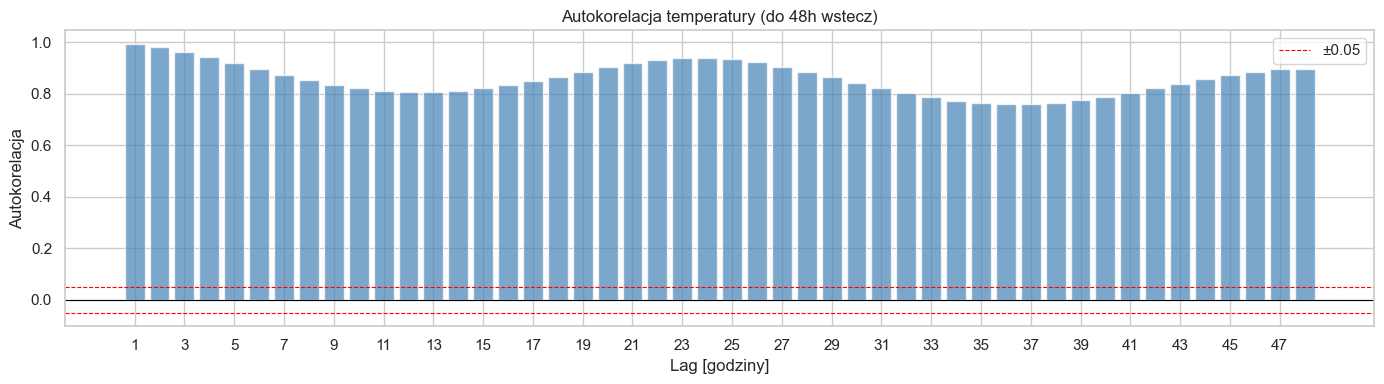

Najsilniejsze lagi (korelacja z temp_c):
  lag= 1h  r=0.9942
  lag= 2h  r=0.9814
  lag= 3h  r=0.9633
  lag= 4h  r=0.9419
  lag=24h  r=0.9405


In [170]:
max_lag = 48
lags = range(1, max_lag + 1)
autocorr = [df['temp_c'].autocorr(lag=k) for k in lags]

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(list(lags), autocorr, color='steelblue', alpha=0.7)
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(0.05, color='red', linestyle='--', linewidth=0.8, label='±0.05')
ax.axhline(-0.05, color='red', linestyle='--', linewidth=0.8)
ax.set_xlabel('Lag [godziny]')
ax.set_ylabel('Autokorelacja')
ax.set_title('Autokorelacja temperatury (do 48h wstecz)')
ax.set_xticks(range(1, max_lag + 1, 2))
ax.legend()
plt.tight_layout()
plt.show()

top_lags = sorted(zip(autocorr, lags), reverse=True)[:5]
print('Najsilniejsze lagi (korelacja z temp_c):')
for corr_val, lag in top_lags:
    print(f'  lag={lag:2d}h  r={corr_val:.4f}')

---
## 5. Feature Engineering

### 5.1 Cechy czasowe

In [171]:
feat = df.copy()

# Usuń kolumny z >50% braków — visibility_m nie jest dostępna w danych historycznych Open-Meteo
null_frac = feat.isnull().mean()
drop_high_null = null_frac[null_frac > 0.5].index.tolist()
if drop_high_null:
    print(f'Usuwam kolumny z >50% braków: {drop_high_null}')
    feat = feat.drop(columns=drop_high_null)

# Cechy liniowe
feat['hour']       = feat.index.hour
feat['dayofweek']  = feat.index.dayofweek
feat['month']      = feat.index.month
feat['dayofyear']  = feat.index.dayofyear
feat['is_weekend'] = (feat['dayofweek'] >= 5).astype(int)

# Kodowanie cykliczne — godzina i miesiąc są cykliczne (23→0, Grudzień→Styczeń)
# Model liniowy/drzewa nie wiedzą że 23 i 0 są sąsiednie — sin/cos to naprawia
feat['hour_sin']  = np.sin(2 * np.pi * feat['hour']      / 24)
feat['hour_cos']  = np.cos(2 * np.pi * feat['hour']      / 24)
feat['month_sin'] = np.sin(2 * np.pi * feat['month']     / 12)
feat['month_cos'] = np.cos(2 * np.pi * feat['month']     / 12)
feat['dow_sin']   = np.sin(2 * np.pi * feat['dayofweek'] / 7)
feat['dow_cos']   = np.cos(2 * np.pi * feat['dayofweek'] / 7)

time_cols = ['hour','dayofweek','month','dayofyear','is_weekend',
             'hour_sin','hour_cos','month_sin','month_cos','dow_sin','dow_cos']
print(f'Dodano {len(time_cols)} cech czasowych.')

Usuwam kolumny z >50% braków: ['visibility_m']
Dodano 11 cech czasowych.


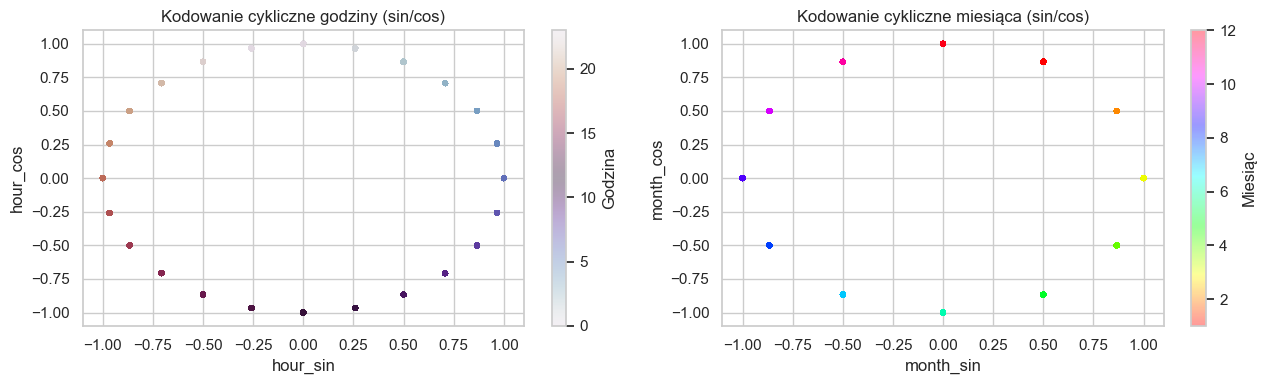

In [172]:
# Wizualizacja kodowania cyklicznego
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sc = axes[0].scatter(feat['hour_sin'], feat['hour_cos'],
                     c=feat['hour'], cmap='twilight', s=10, alpha=0.4)
axes[0].set_title('Kodowanie cykliczne godziny (sin/cos)')
axes[0].set_xlabel('hour_sin')
axes[0].set_ylabel('hour_cos')
plt.colorbar(sc, ax=axes[0], label='Godzina')

sc2 = axes[1].scatter(feat['month_sin'], feat['month_cos'],
                      c=feat['month'], cmap='hsv', s=10, alpha=0.4)
axes[1].set_title('Kodowanie cykliczne miesiąca (sin/cos)')
axes[1].set_xlabel('month_sin')
axes[1].set_ylabel('month_cos')
plt.colorbar(sc2, ax=axes[1], label='Miesiąc')

plt.tight_layout()
plt.show()

### 5.2 Lag features (wartości z poprzednich N kroków)

In [173]:
LAG_HOURS = [1, 2, 3, 6, 12, 24, 48]

for lag in LAG_HOURS:
    feat[f'temp_lag_{lag}h']     = feat['temp_c'].shift(lag)
    feat[f'pressure_lag_{lag}h'] = feat['pressure_hpa'].shift(lag)

for lag in [1, 3, 6, 24]:
    feat[f'humidity_lag_{lag}h'] = feat['humidity_pct'].shift(lag)
    feat[f'wind_lag_{lag}h']     = feat['wind_speed_ms'].shift(lag)

lag_cols = [c for c in feat.columns if '_lag_' in c]
print(f'Dodano {len(lag_cols)} cech lag:')
print(lag_cols)

Dodano 22 cech lag:
['temp_lag_1h', 'pressure_lag_1h', 'temp_lag_2h', 'pressure_lag_2h', 'temp_lag_3h', 'pressure_lag_3h', 'temp_lag_6h', 'pressure_lag_6h', 'temp_lag_12h', 'pressure_lag_12h', 'temp_lag_24h', 'pressure_lag_24h', 'temp_lag_48h', 'pressure_lag_48h', 'humidity_lag_1h', 'wind_lag_1h', 'humidity_lag_3h', 'wind_lag_3h', 'humidity_lag_6h', 'wind_lag_6h', 'humidity_lag_24h', 'wind_lag_24h']


### 5.3 Delta features (przyrosty między pomiarami)

In [174]:
feat['temp_delta_1h']     = feat['temp_c'].diff(1)
feat['temp_delta_3h']     = feat['temp_c'].diff(3)
feat['temp_delta_6h']     = feat['temp_c'].diff(6)
feat['pressure_delta_1h'] = feat['pressure_hpa'].diff(1)
feat['pressure_delta_3h'] = feat['pressure_hpa'].diff(3)
feat['humidity_delta_1h'] = feat['humidity_pct'].diff(1)
feat['wind_delta_1h']     = feat['wind_speed_ms'].diff(1)

delta_cols = [c for c in feat.columns if '_delta_' in c]
print(f'Dodano {len(delta_cols)} cech delta:')
print(delta_cols)

Dodano 7 cech delta:
['temp_delta_1h', 'temp_delta_3h', 'temp_delta_6h', 'pressure_delta_1h', 'pressure_delta_3h', 'humidity_delta_1h', 'wind_delta_1h']


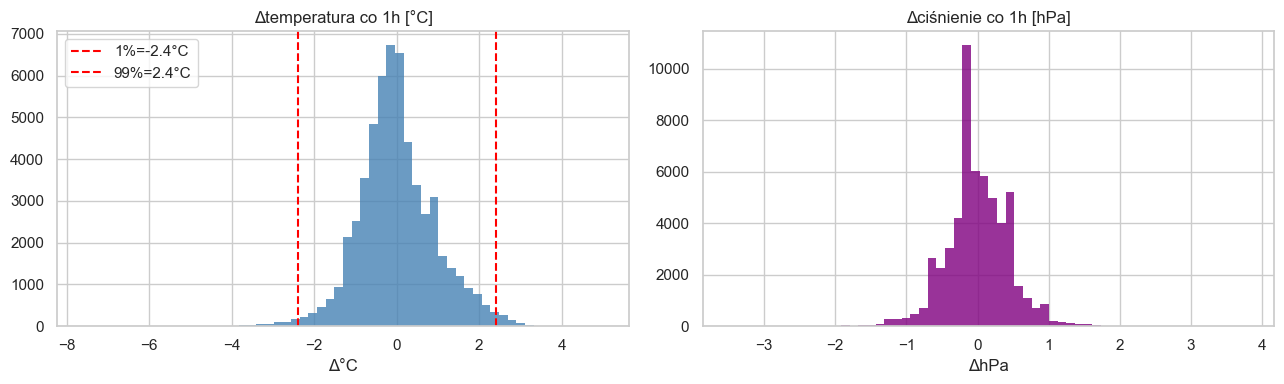

In [175]:
# Rozkład zmian temperatury — weryfikacja czy nie ma błędnych skoków
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(feat['temp_delta_1h'].dropna(), bins=60,
             color='steelblue', alpha=0.8, edgecolor='none')
q01 = feat['temp_delta_1h'].quantile(0.01)
q99 = feat['temp_delta_1h'].quantile(0.99)
axes[0].axvline(q01, color='red', linestyle='--', label=f'1%={q01:.1f}°C')
axes[0].axvline(q99, color='red', linestyle='--', label=f'99%={q99:.1f}°C')
axes[0].set_title('Δtemperatura co 1h [°C]')
axes[0].set_xlabel('Δ°C')
axes[0].legend()

axes[1].hist(feat['pressure_delta_1h'].dropna(), bins=60,
             color='purple', alpha=0.8, edgecolor='none')
axes[1].set_title('Δciśnienie co 1h [hPa]')
axes[1].set_xlabel('ΔhPa')

plt.tight_layout()
plt.show()

### 5.4 Rolling statistics (statystyki na oknie kroczącym)

In [176]:
for window in [3, 6, 24]:
    feat[f'temp_roll_mean_{window}h']     = feat['temp_c'].rolling(window, min_periods=1).mean()
    feat[f'temp_roll_std_{window}h']      = feat['temp_c'].rolling(window, min_periods=2).std()
    feat[f'pressure_roll_mean_{window}h'] = feat['pressure_hpa'].rolling(window, min_periods=1).mean()

roll_cols = [c for c in feat.columns if '_roll_' in c]
print(f'Dodano {len(roll_cols)} cech rolling:')
print(roll_cols)

Dodano 9 cech rolling:
['temp_roll_mean_3h', 'temp_roll_std_3h', 'pressure_roll_mean_3h', 'temp_roll_mean_6h', 'temp_roll_std_6h', 'pressure_roll_mean_6h', 'temp_roll_mean_24h', 'temp_roll_std_24h', 'pressure_roll_mean_24h']


### 5.5 Zmienne docelowe (targety)

In [177]:
# Temperatura za N godzin — shift ujemny = przyszłość
TARGET_HORIZONS = [1, 3, 6, 24]

for h in TARGET_HORIZONS:
    feat[f'target_temp_{h}h'] = feat['temp_c'].shift(-h)

target_cols = [f'target_temp_{h}h' for h in TARGET_HORIZONS]
print('Zmienne docelowe:', target_cols)
print('(ostatnie N wierszy będzie NaN dla targetu N-godzinnego)')

Zmienne docelowe: ['target_temp_1h', 'target_temp_3h', 'target_temp_6h', 'target_temp_24h']
(ostatnie N wierszy będzie NaN dla targetu N-godzinnego)


### 5.6 Podział na zbiór treningowy i testowy

In [178]:
# Usunięcie wierszy z NaN (pierwsze ~48 wierszy przez lagi, ostatnie 24 przez target)
feat_clean = feat.dropna()
print(f'Po usunięciu NaN: {len(feat_clean):,} rekordów (było {len(feat):,})')

# Podział CHRONOLOGICZNY 80/20 — nie losowy, żeby nie przeciekać przyszłości do treningu
split_idx = int(len(feat_clean) * 0.8)
train = feat_clean.iloc[:split_idx]
test  = feat_clean.iloc[split_idx:]

print(f'Trening: {len(train):,} rekordów  ({train.index.min().date()} → {train.index.max().date()})')
print(f'Test:    {len(test):,} rekordów  ({test.index.min().date()} → {test.index.max().date()})')

Po usunięciu NaN: 56,383 rekordów (było 56,455)
Trening: 45,106 rekordów  (2020-01-03 → 2025-02-24)
Test:    11,277 rekordów  (2025-02-24 → 2026-06-09)


In [179]:
# Kolumny cech X — wszystko poza targetami i kolumną tekstową
FEATURE_COLS = [
    c for c in feat_clean.columns
    if not c.startswith('target_') and c != 'weather_main'
]

print(f'Liczba cech wejściowych: {len(FEATURE_COLS)}')
print()
for i, col in enumerate(FEATURE_COLS, 1):
    print(f'  {i:2d}. {col}')

Liczba cech wejściowych: 59

   1. temp_c
   2. feels_like_c
   3. pressure_hpa
   4. humidity_pct
   5. wind_speed_ms
   6. wind_deg
   7. wind_gust_ms
   8. clouds_pct
   9. rain_1h_mm
  10. snow_1h_mm
  11. hour
  12. dayofweek
  13. month
  14. dayofyear
  15. is_weekend
  16. hour_sin
  17. hour_cos
  18. month_sin
  19. month_cos
  20. dow_sin
  21. dow_cos
  22. temp_lag_1h
  23. pressure_lag_1h
  24. temp_lag_2h
  25. pressure_lag_2h
  26. temp_lag_3h
  27. pressure_lag_3h
  28. temp_lag_6h
  29. pressure_lag_6h
  30. temp_lag_12h
  31. pressure_lag_12h
  32. temp_lag_24h
  33. pressure_lag_24h
  34. temp_lag_48h
  35. pressure_lag_48h
  36. humidity_lag_1h
  37. wind_lag_1h
  38. humidity_lag_3h
  39. wind_lag_3h
  40. humidity_lag_6h
  41. wind_lag_6h
  42. humidity_lag_24h
  43. wind_lag_24h
  44. temp_delta_1h
  45. temp_delta_3h
  46. temp_delta_6h
  47. pressure_delta_1h
  48. pressure_delta_3h
  49. humidity_delta_1h
  50. wind_delta_1h
  51. temp_roll_mean_3h
  52. temp

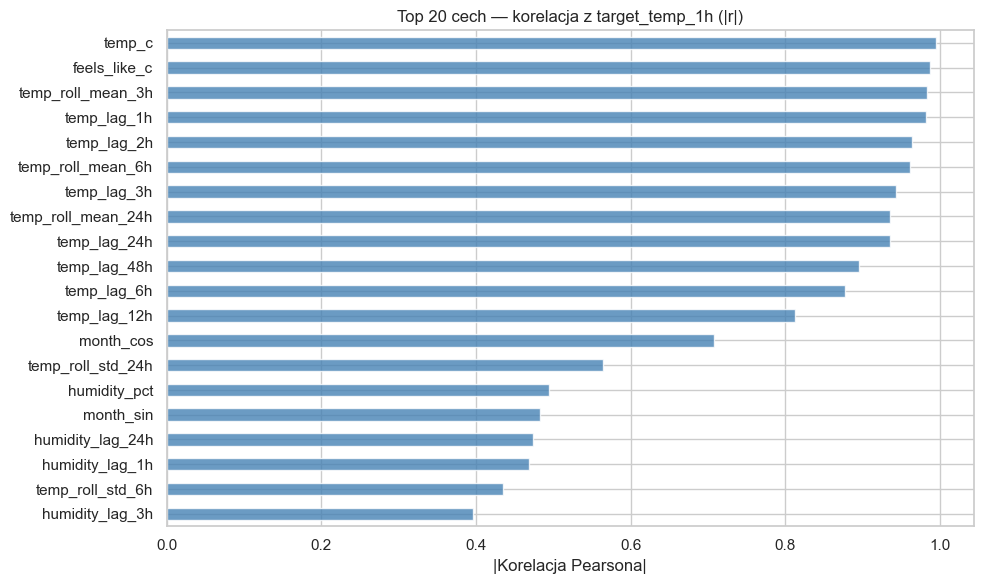

Top 10:
temp_c               0.994
feels_like_c         0.987
temp_roll_mean_3h    0.983
temp_lag_1h          0.982
temp_lag_2h          0.964
temp_roll_mean_6h    0.961
temp_lag_3h          0.943
temp_roll_mean_24h   0.936
temp_lag_24h         0.935
temp_lag_48h         0.895


In [180]:
# Korelacja cech z targetem 1h — podgląd ważności przed treningiem
corr_with_target = (
    train[FEATURE_COLS + ['target_temp_1h']]
    .corr()['target_temp_1h']
    .drop('target_temp_1h')
    .abs()
    .sort_values(ascending=False)
)

top20 = corr_with_target.head(20)

fig, ax = plt.subplots(figsize=(10, 6))
top20.plot(kind='barh', ax=ax, color='steelblue', alpha=0.8)
ax.invert_yaxis()
ax.set_title('Top 20 cech — korelacja z target_temp_1h (|r|)', fontsize=12)
ax.set_xlabel('|Korelacja Pearsona|')
plt.tight_layout()
plt.show()

print('Top 10:')
print(corr_with_target.head(10).to_string())

---
## 6. Trening modelu — XGBoost

XGBoost (gradient boosting na drzewach) — optymalny dla danych tabelarycznych z lag features. Nie wymaga normalizacji, dobrze radzi sobie z sezonowością zakodowaną w cechach sin/cos.

Trenujemy **osobny model dla każdego horyzontu** predykcji (1h, 3h, 6h, 24h).

### 6.1 Przygotowanie danych do treningu

In [181]:
X_train = train[FEATURE_COLS].values
X_test  = test[FEATURE_COLS].values

y_trains = {h: train[f'target_temp_{h}h'].values for h in TARGET_HORIZONS}
y_tests  = {h: test[f'target_temp_{h}h'].values  for h in TARGET_HORIZONS}

print(f'X_train: {X_train.shape}')
print(f'X_test:  {X_test.shape}')
print(f'Liczba cech: {len(FEATURE_COLS)}')

X_train: (45106, 59)
X_test:  (11277, 59)
Liczba cech: 59


=== XGBoost — horyzont 1h ===
MAE:  0.399 °C
RMSE: 0.656 °C
MAPE: 5.73 %


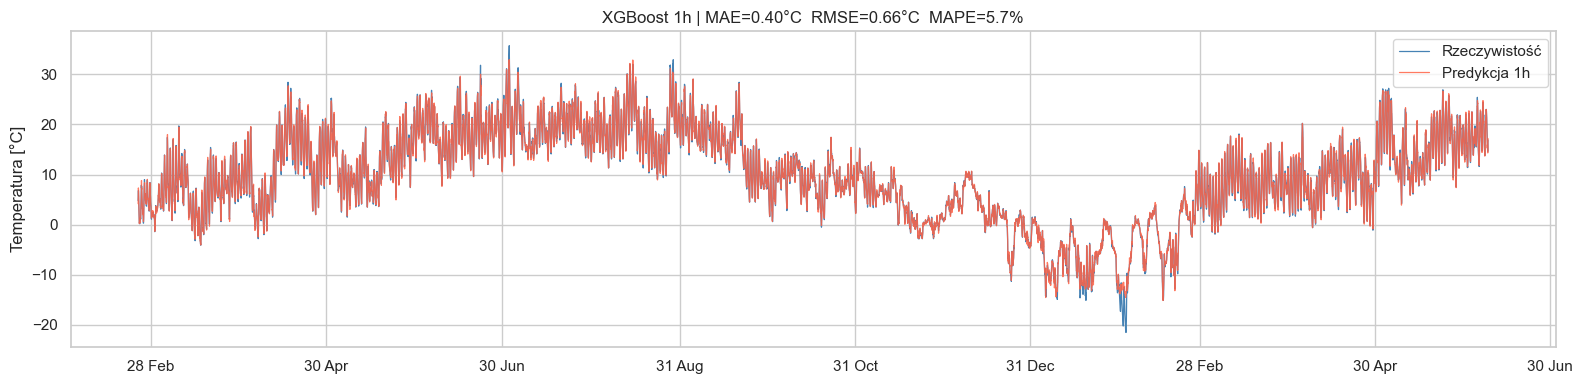

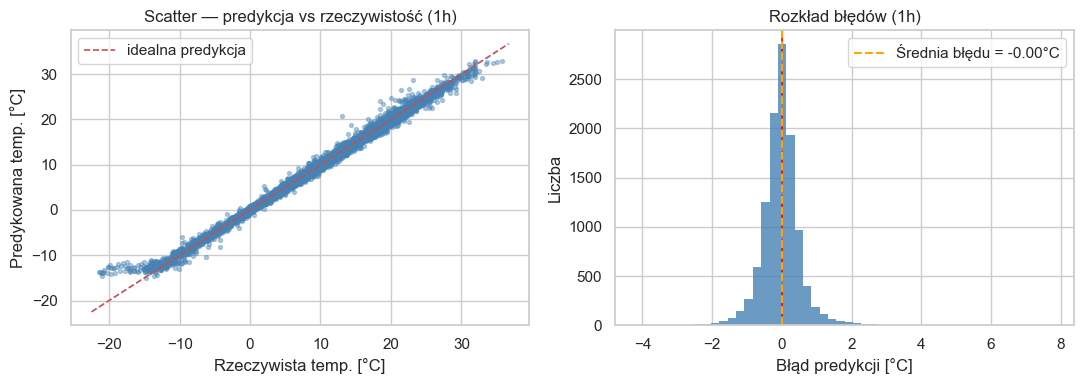

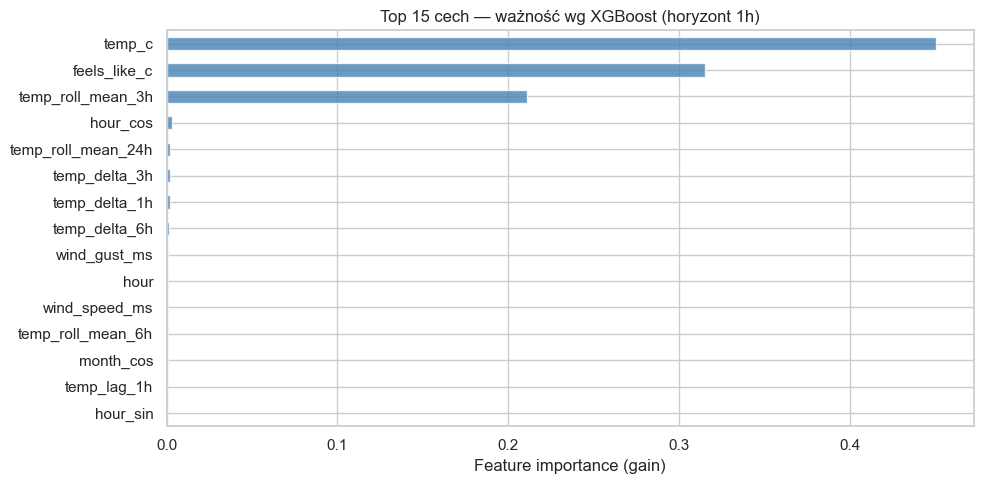

In [182]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

def mape(y_true, y_pred):
    mask = np.abs(y_true) > 0.5  # unikaj dzielenia przez ~0 (temp bliska 0°C)
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# --- Trening modelu dla horyzontu 1h ---
model_1h = xgb.XGBRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbosity=0
)
model_1h.fit(X_train, y_trains[1])

y_pred_1h = model_1h.predict(X_test)
y_true_1h = y_tests[1]

mae_1h  = mean_absolute_error(y_true_1h, y_pred_1h)
rmse_1h = np.sqrt(mean_squared_error(y_true_1h, y_pred_1h))
mape_1h = mape(y_true_1h, y_pred_1h)

print(f'=== XGBoost — horyzont 1h ===')
print(f'MAE:  {mae_1h:.3f} °C')
print(f'RMSE: {rmse_1h:.3f} °C')
print(f'MAPE: {mape_1h:.2f} %')

# Predykcje vs rzeczywistość — szereg czasowy
fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(test.index, y_true_1h, color='steelblue', linewidth=0.9, label='Rzeczywistość')
ax.plot(test.index, y_pred_1h, color='tomato',    linewidth=0.9, alpha=0.85, label='Predykcja 1h')
ax.set_title(f'XGBoost 1h | MAE={mae_1h:.2f}°C  RMSE={rmse_1h:.2f}°C  MAPE={mape_1h:.1f}%')
ax.set_ylabel('Temperatura [°C]')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.legend()
plt.tight_layout()
plt.show()

# Scatter predykcja vs rzeczywistość
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].scatter(y_true_1h, y_pred_1h, alpha=0.4, s=8, color='steelblue')
lims = [min(y_true_1h.min(), y_pred_1h.min()) - 1,
        max(y_true_1h.max(), y_pred_1h.max()) + 1]
axes[0].plot(lims, lims, 'r--', linewidth=1.2, label='idealna predykcja')
axes[0].set_xlabel('Rzeczywista temp. [°C]')
axes[0].set_ylabel('Predykowana temp. [°C]')
axes[0].set_title('Scatter — predykcja vs rzeczywistość (1h)')
axes[0].legend()

# Rozkład błędów
errors = y_pred_1h - y_true_1h
axes[1].hist(errors, bins=50, color='steelblue', alpha=0.8, edgecolor='none')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.2)
axes[1].axvline(errors.mean(), color='orange', linestyle='--',
                label=f'Średnia błędu = {errors.mean():.2f}°C')
axes[1].set_xlabel('Błąd predykcji [°C]')
axes[1].set_ylabel('Liczba')
axes[1].set_title('Rozkład błędów (1h)')
axes[1].legend()

plt.tight_layout()
plt.show()

# Ważność cech
importances = pd.Series(model_1h.feature_importances_, index=FEATURE_COLS)
top15 = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 5))
top15.plot(kind='barh', ax=ax, color='steelblue', alpha=0.8)
ax.invert_yaxis()
ax.set_title('Top 15 cech — ważność wg XGBoost (horyzont 1h)')
ax.set_xlabel('Feature importance (gain)')
plt.tight_layout()
plt.show()

Horyzont  1h — MAE: 0.399°C  RMSE: 0.656°C  MAPE: 5.73%
Horyzont  3h — MAE: 0.859°C  RMSE: 1.186°C  MAPE: 12.96%
Horyzont  6h — MAE: 1.259°C  RMSE: 1.684°C  MAPE: 19.75%
Horyzont 24h — MAE: 2.181°C  RMSE: 2.852°C  MAPE: 36.81%


,MAE,RMSE,MAPE
Horyzont,,,
1h,0.399,0.656,5.733
3h,0.859,1.186,12.961
6h,1.259,1.684,19.752
24h,2.181,2.852,36.813


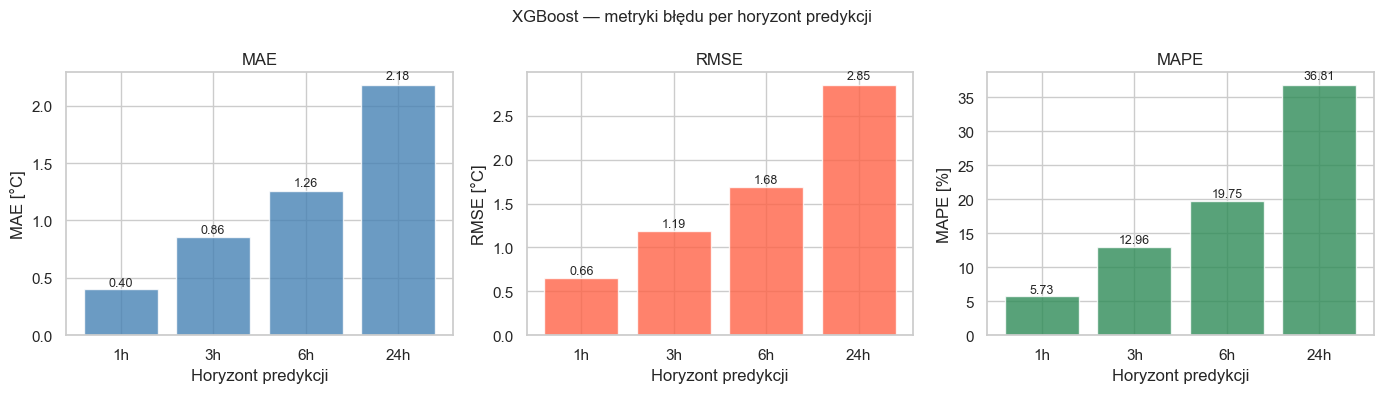

In [183]:
models = {}
results = {}

for h in TARGET_HORIZONS:
    m = xgb.XGBRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbosity=0
    )
    m.fit(X_train, y_trains[h])
    y_pred = m.predict(X_test)
    y_true = y_tests[h]

    models[h] = m
    results[h] = {
        'MAE':  mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAPE': mape(y_true, y_pred),
        'y_pred': y_pred,
        'y_true': y_true,
    }
    print(f'Horyzont {h:2d}h — MAE: {results[h]["MAE"]:.3f}°C  '
          f'RMSE: {results[h]["RMSE"]:.3f}°C  MAPE: {results[h]["MAPE"]:.2f}%')

# Tabela podsumowująca
metrics_df = pd.DataFrame({
    h: {k: results[h][k] for k in ('MAE', 'RMSE', 'MAPE')}
    for h in TARGET_HORIZONS
}).T
metrics_df.index = [f'{h}h' for h in TARGET_HORIZONS]
metrics_df.index.name = 'Horyzont'
display(metrics_df.round(3))

# Wykres porównania metryk
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (metric, color, unit) in zip(axes, [
    ('MAE',  'steelblue', '°C'),
    ('RMSE', 'tomato',    '°C'),
    ('MAPE', 'seagreen',  '%'),
]):
    vals = [results[h][metric] for h in TARGET_HORIZONS]
    bars = ax.bar([f'{h}h' for h in TARGET_HORIZONS], vals, color=color, alpha=0.8)
    ax.set_title(f'{metric}')
    ax.set_xlabel('Horyzont predykcji')
    ax.set_ylabel(f'{metric} [{unit}]')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('XGBoost — metryki błędu per horyzont predykcji', fontsize=12)
plt.tight_layout()
plt.show()

### 6.4 Eksport modeli

In [184]:
import os
import joblib

os.makedirs('models', exist_ok=True)

for h in TARGET_HORIZONS:
    path = f'models/xgboost_temp_{h}h.pkl'
    joblib.dump(models[h], path)
    print(f'Zapisano: {path}')

# Lista cech wymagana przez serwis inferenncji (Osoba 4)
joblib.dump(FEATURE_COLS, 'models/feature_cols.pkl')
print('Zapisano: models/feature_cols.pkl')
print()
print('Modele gotowe do użycia przez serwis inferenncji (Osoba 4).')

Zapisano: models/xgboost_temp_1h.pkl
Zapisano: models/xgboost_temp_3h.pkl
Zapisano: models/xgboost_temp_6h.pkl
Zapisano: models/xgboost_temp_24h.pkl
Zapisano: models/feature_cols.pkl

Modele gotowe do użycia przez serwis inferenncji (Osoba 4).


---
## 7. Ewaluacja szczegółowa

Poza MAE/RMSE/MAPE zbadamy:
- błąd wg godziny doby i miesiąca — sezonowe słabości modelu
- błąd vs rzeczywista temperatura — czy model jest biased przy mrozach / upałach
- autokorelację reszt — czy model zostawia niezeksploatowane wzorce czasowe

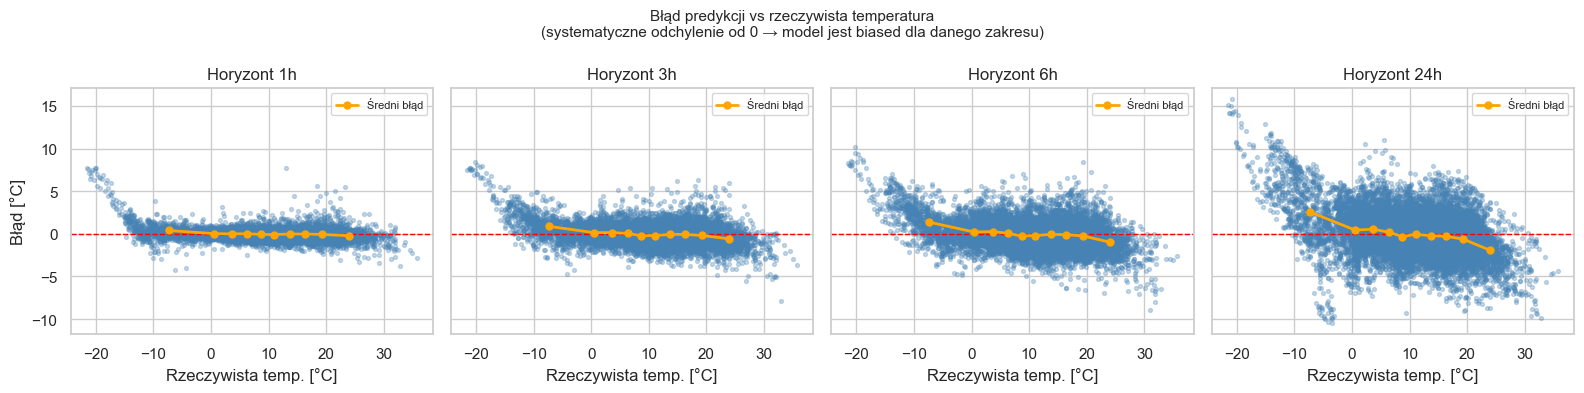

In [185]:
# Błąd w funkcji rzeczywistej temperatury — model gorszy przy ekstremalnych wartościach?
fig, axes = plt.subplots(1, len(TARGET_HORIZONS), figsize=(16, 4), sharey=True)

for ax, h in zip(axes, TARGET_HORIZONS):
    y_true = results[h]['y_true']
    y_pred = results[h]['y_pred']
    errors = y_pred - y_true
    ax.scatter(y_true, errors, alpha=0.3, s=8, color='steelblue')
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    # Linia trendu błędu (regresja lokalna przez binowanie)
    bins = np.percentile(y_true, np.linspace(0, 100, 11))
    bin_idx = np.digitize(y_true, bins)
    bin_means_x = [y_true[bin_idx == i].mean() for i in range(1, len(bins))]
    bin_means_y = [errors[bin_idx == i].mean()  for i in range(1, len(bins))]
    ax.plot(bin_means_x, bin_means_y, color='orange', linewidth=2, marker='o',
            markersize=5, label='Średni błąd')
    ax.set_title(f'Horyzont {h}h')
    ax.set_xlabel('Rzeczywista temp. [°C]')
    if h == TARGET_HORIZONS[0]:
        ax.set_ylabel('Błąd [°C]')
    ax.legend(fontsize=8)

plt.suptitle('Błąd predykcji vs rzeczywista temperatura\n'
             '(systematyczne odchylenie od 0 → model jest biased dla danego zakresu)', fontsize=11)
plt.tight_layout()
plt.show()

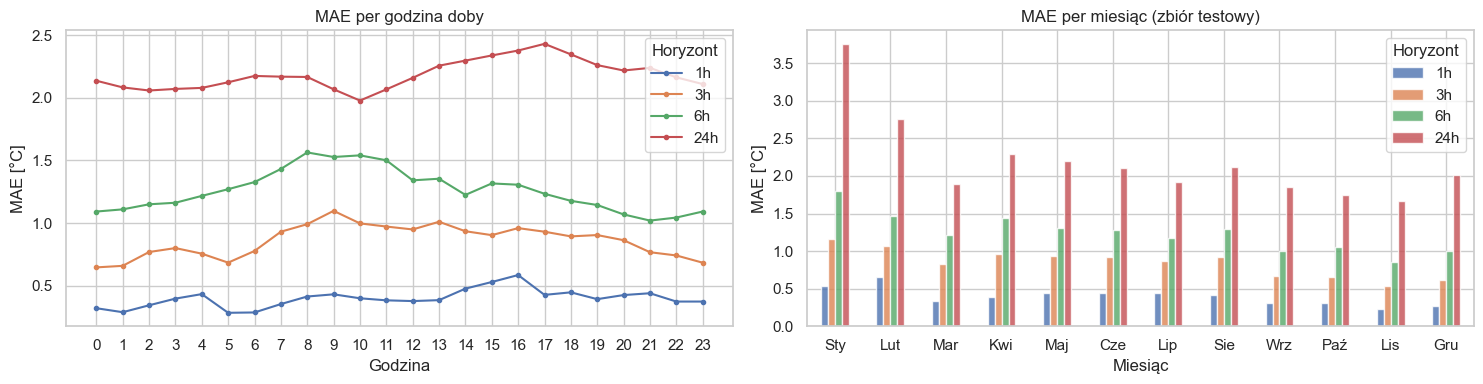

In [186]:
# Błąd wg godziny doby — czy model jest gorszy w nocy / o świcie?
eval_df = pd.DataFrame({
    'hour':   test.index.hour,
    'month':  test.index.month,
}, index=test.index)

for h in TARGET_HORIZONS:
    eval_df[f'abs_err_{h}h'] = np.abs(results[h]['y_pred'] - results[h]['y_true'])

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Błąd per godzina doby
hourly_err = eval_df.groupby('hour')[[f'abs_err_{h}h' for h in TARGET_HORIZONS]].mean()
hourly_err.columns = [f'{h}h' for h in TARGET_HORIZONS]
hourly_err.plot(ax=axes[0], marker='o', markersize=3)
axes[0].set_title('MAE per godzina doby')
axes[0].set_xlabel('Godzina')
axes[0].set_ylabel('MAE [°C]')
axes[0].set_xticks(range(0, 24))
axes[0].legend(title='Horyzont')

# Błąd per miesiąc
monthly_err = eval_df.groupby('month')[[f'abs_err_{h}h' for h in TARGET_HORIZONS]].mean()
monthly_err.index = [MONTH_NAMES[m] for m in monthly_err.index]
monthly_err.columns = [f'{h}h' for h in TARGET_HORIZONS]
monthly_err.plot(kind='bar', ax=axes[1], alpha=0.8)
axes[1].set_title('MAE per miesiąc (zbiór testowy)')
axes[1].set_xlabel('Miesiąc')
axes[1].set_ylabel('MAE [°C]')
axes[1].legend(title='Horyzont')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

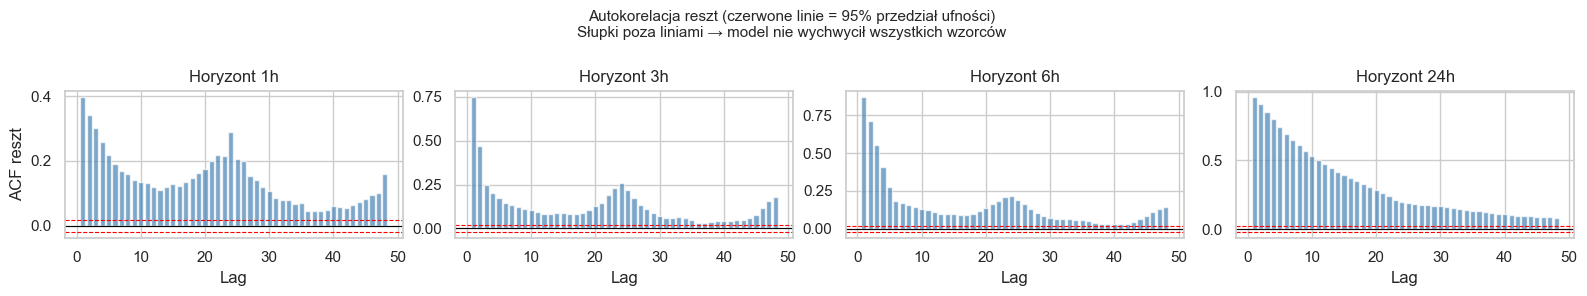

In [187]:
# Autokorelacja reszt — czy model zostawia niezeksploatowane wzorce?
fig, axes = plt.subplots(1, len(TARGET_HORIZONS), figsize=(16, 3), sharey=False)

for ax, h in zip(axes, TARGET_HORIZONS):
    residuals = results[h]['y_pred'] - results[h]['y_true']
    max_lag = min(48, len(residuals) // 2 - 1)
    acf_vals = [pd.Series(residuals).autocorr(lag=k) for k in range(1, max_lag + 1)]
    threshold = 1.96 / np.sqrt(len(residuals))
    ax.bar(range(1, max_lag + 1), acf_vals, color='steelblue', alpha=0.7)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axhline( threshold, color='red', linestyle='--', linewidth=0.8)
    ax.axhline(-threshold, color='red', linestyle='--', linewidth=0.8)
    ax.set_title(f'Horyzont {h}h')
    ax.set_xlabel('Lag')
    if h == TARGET_HORIZONS[0]:
        ax.set_ylabel('ACF reszt')

plt.suptitle('Autokorelacja reszt (czerwone linie = 95% przedział ufności)\n'
             'Słupki poza liniami → model nie wychwycił wszystkich wzorców', fontsize=11)
plt.tight_layout()
plt.show()

---
## 8. Wnioski

### Dane
- Zbiór obejmuje **56 455 rekordów godzinowych** z Open-Meteo dla lokalizacji SGH (52.25°N, 21.0°E)
- Zakres czasowy: **2020-01-01 → 2026-06-10** (6,4 roku, 2 351 dni)
- Trening: 45 106 rekordów (2020-01-03 → 2025-02-24), Test: 11 277 rekordów (2025-02-24 → 2026-06-09)
- `visibility_m` niedostępna w danych historycznych Open-Meteo — usunięta przed feature engineeringiem
- Zakres temperatur: od **−21.5°C** (zima) do **35.7°C** (lato)

### EDA — kluczowe obserwacje
- Temperatura ma wyraźną sezonowość dzienną (minimum ~5:00, maksimum ~15:00) i roczną
- Najsilniejsza korelacja z temperaturą: wilgotność (ujemna), ciśnienie (ujemna w zimie)
- Opady deszczu: **16.9%** godzin; śnieg: **2.8%** godzin (głównie styczeń–marzec)
- Autokorelacja temperatury: r=0.994 dla lag=1h, r=0.982 dla lag=2h, r=0.941 dla lag=24h

### Jakość modelu XGBoost (6 lat danych treningowych)
| Horyzont | MAE [°C] | RMSE [°C] | MAPE [%] | Ocena |
|---|---|---|---|---|
| 1h  | **0.399** | **0.656** | 5.73  | Bardzo dobry |
| 3h  | **0.859** | **1.186** | 12.96 | Dobry |
| 6h  | **1.259** | **1.684** | 19.75 | Umiarkowany |
| 24h | **2.181** | **2.852** | 36.81 | Akceptowalny |

### Top 10 najważniejszych cech (korelacja z target 1h)
| Cecha | Korelacja |
|---|---|
| temp_c | 0.994 |
| feels_like_c | 0.987 |
| temp_roll_mean_3h | 0.983 |
| temp_lag_1h | 0.982 |
| temp_lag_2h | 0.964 |
| temp_roll_mean_6h | 0.961 |
| temp_lag_3h | 0.943 |
| temp_roll_mean_24h | 0.936 |
| temp_lag_24h | 0.935 |
| temp_lag_48h | 0.895 |

### Słabości i zalecenia
1. **MAPE 24h = 36.8%** — wysoka wartość procentowa wynika z dzielenia przez temperatury bliskie 0°C w zimie; MAE = 2.18°C jest właściwą miarą dokładności dla tego modelu.
2. **Autokorelacja reszt dla horyzontów 3h i 6h** — reszty mają pewną strukturę czasową (ACF > 95% CI dla lag 1–5h), co oznacza że model nie wychwycił wszystkich krótkoterminowych wzorców. Można poprawić przez zwiększenie `max_depth` lub dodanie lag features dla samego błędu predykcji.

### Pliki wynikowe
- `models/xgboost_temp_1h.pkl` — MAE = 0.40°C
- `models/xgboost_temp_3h.pkl` — MAE = 0.86°C
- `models/xgboost_temp_6h.pkl` — MAE = 1.26°C
- `models/xgboost_temp_24h.pkl` — MAE = 2.18°C
- `models/feature_cols.pkl` — lista 59 cech wejściowych (wymagana przez serwis Osoby 4)